<span style="Color: olive; font-size:40px">**NORMALIZATION AND CLUSTERING**</span>

⚠️  <span style="color: orange; font-size:18px">***Restart Kernel***</span>

<span style="font-size:16px; font-weight:bold"> In this notebook, data will be normalized, integrated, and clustered. </span> 

<span style="font-size:14px; color:red; font-weight:bold"> <strong>Note:</strong> All newly created notebooks must include an initial cell for environment setup and memory usage management. </span>

<span style="color:olive; font-size:16px">**Import libraries**</span>

In [1]:
import scanpy as sc
import anndata as ad
import scanpy.external as sce
import numpy as np
import pandas as pd
import psutil, gc, os, zipfile
import scrublet as scr
import matplotlib.pyplot as plt
import matplotlib.backends.backend_pdf as pdf_backend
import seaborn as sns
from pathlib import Path
from scipy.sparse import issparse
from scipy.sparse import csr_matrix
from scipy.stats import median_abs_deviation
from tqdm import tqdm

In [2]:

sc.settings.n_jobs     = 4                  # Use multiple CPU cores for parallel processing (if supported by the function)
sc.settings.verbosity  = 2              # Set verbosity level (0 = errors only, 1 = warnings, 2 = info, 3 = debug)  
sc.settings.figdir     = '../results/'    # Directory to save figures
np.random.seed(42) 

raw_dir  = Path('../data/Raw_matrix')
ckpt_dir = Path('../checkpoints')
ckpt_dir.mkdir(exist_ok=True)


def check_ram():
    ram = psutil.Process().memory_info().rss / 1e9
    print(f"RAM in use: {ram:.1f} GB")
    if ram > 11:
        print("⚠️ High RAM — consider restarting kernel soon")

def find_matrix_folder(patient_dir):
    for subfolder in patient_dir.iterdir():
        if subfolder.is_dir() and any(subfolder.rglob('*.mtx*')):
            return subfolder
    return None

def is_outlier(adata, metric, n_mads=5):
    """Detect outliers based on the median absolute deviation (MAD) method.
    Parameters:
    adata: AnnData object containing the data.
    metric: The column name in adata.obs to check for outliers.
    n_mads: The number of MADs to use as the threshold for outlier detection.
    Returns:    A boolean Series indicating which cells are outliers.
    """
    values = adata.obs[metric]
    median = np.median(values)
    mad = median_abs_deviation(values, scale='normal')
    lower_bound = median - n_mads * mad
    upper_bound = median + n_mads * mad
    return (values < lower_bound) | (values > upper_bound)


check_ram()

RAM in use: 0.4 GB


<span style="font-size:18px; color: olive">**DATA NORMALIZATION**</span>

===========================================================================================================

<span style="font-size:14px; color:orange">***A provisional normalization will be performed to enable dimensionality reduction and clustering. A more rigorous approach will be applied later after doublet removal and QC reassessment.***</span>

===========================================================================================================

<Axes: xlabel='total_counts', ylabel='Count'>

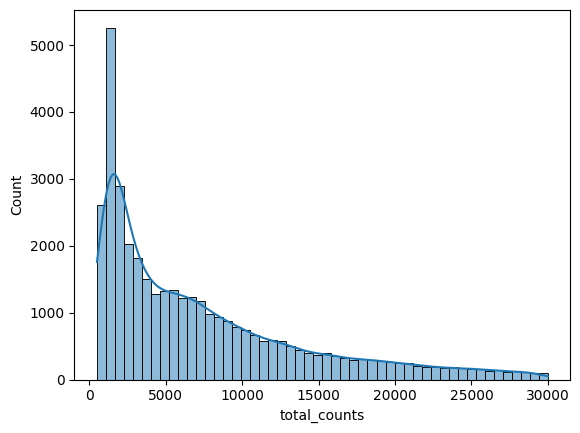

In [5]:
adata=sc.read_h5ad(ckpt_dir / 'adata_postQC.h5ad')
sns.histplot(adata.obs['total_counts'], bins=50, kde=True)

<span style="font-size:14px">***Due to the needs of the project, we will perform a hybrid normalization approach***

| Your goal                                    | Best method                                                             | Why                                                                                                                                |
| -------------------------------------------- | ----------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------- |
| UMAP + clustering + Harmony batch correction | Shifted logarithm (normalize_total + log1p)                             | Best variance stabilization for dimensionality reduction sc-best-practices                                                         |
| Selecting biologically variable genes (HVGs) | Analytical Pearson residuals (sc.experimental.pp.highly_variable_genes) | Strongly outperforms log-norm for HVG selection, especially for rare cells like γδ T pubmed.ncbi.nlm.nih                           |
| DEG analysis (Non-res vs Res endothelial)    | Shifted logarithm on raw counts via adata.raw or layers['raw_counts']   | Standard for Wilcoxon + rank_genes_groups sc-best-practices                                                                        |
| Cross-patient batch correction (12 patients) | Shifted log + Harmony                                                   | Scran is better for batch correction in theory but requires R; Harmony on log-normalized data is the practical Python choice nygen |

   - <span style="color: teal; font-size:15px">**Step 1: Provisional normalization for dimensionality reduction and clustering**</span>
      - <span style="font-size:13px">**Pearson residuals for Highly Variable Gene (HVG) selection**</span>
      - <span style="font-size:13px">**Log-normalization for dimensionality reduction and clustering**</span>

   - <span style="color:teal; font-size:14px">**Pearson Residuals HVG Selection**</span>

In [7]:
if 'raw_counts' not in adata.layers:
    adata.layers['raw_counts'] = adata.X.copy()

# 2. HVG selection using Pearson residuals on raw counts (most accurate for defining populations)
# We do this before normalizing adata.X for maximum accuracy
sc.experimental.pp.highly_variable_genes(
    adata, 
    flavor='pearson_residuals', 
    layer='raw_counts', 
    n_top_genes=2500,               # For heterogeneous tumor samples, a larger HVG set can help capture rare subpopulations
    batch_key='patient_id'
)

# Save the HVG results for later use in DE analysis
adata.write_h5ad(ckpt_dir / 'part1_hvg.h5ad')
print("Restart kernel to free memory before proceeding to normalization and clustering steps.")
del adata; gc.collect()

extracting highly variable genes
Restart kernel to free memory before proceeding to normalization and clustering steps.


24730

   - <span style="color:teal; font-size:14px">**Log-normalization for dimensionality reduction and PCA**</span>

<span style="font-size:13px">Main matrix adata.X is log-normalized for dimensionality reduction and clustering, while the raw counts are preserved in adata.layers['raw_counts'] for later use in DE analysis.</span>

normalizing counts per cell
    finished (0:00:00)


c:\Users\dioul\miniconda3\envs\scrna\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=50


c:\Users\dioul\miniconda3\envs\scrna\lib\site-packages\scanpy\preprocessing\_pca\__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    finished (0:00:14)


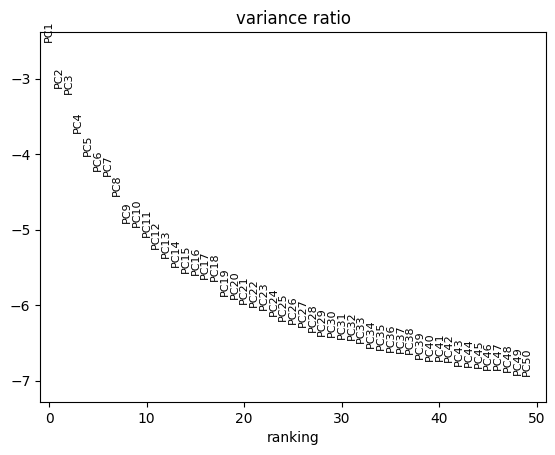

Check '_elbow_plot.pdf' for the number of significant PCs.
 Restart kernel to free memory before proceeding to clustering and visualization steps.


17414

In [ ]:
adata = sc.read_h5ad(ckpt_dir / 'part1_hvg.h5ad')

# Normalization and dimensionality reduction (PCA)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Initial PCA 
sc.pp.scale(adata, max_value=10)            # Scale consume RAM al densificar la matriz
sc.tl.pca(adata, n_comps=50, use_highly_variable=True)      #We calculate 50 PCs to have a full picture of variance structure.

# ELBOW PLOT
# This will help us determine significant PCs for downstream analysis.
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True, save='_elbow_plot.pdf')
plt.show()


# Save the integrated data for clustering and visualization
adata.write_h5ad(ckpt_dir / 'part2_PCA.h5ad')
print("Check '_elbow_plot.pdf' for the number of significant PCs.\n Restart kernel to free memory before proceeding to clustering and visualization steps.")
del adata; gc.collect()


In [3]:
check_ram()

RAM in use: 0.4 GB


   - <span style="color: teal; font-size:14px">**INTEGRATION (Harmony) and CLUSTERING**
   
      - <span style="font-size:13px">**By performing integration using Harmony, we account for batch effects and patient-specific variations, enabling more accurate clustering of cells.**</span>

In [ ]:
"""""
# After examining the elbow plot, we choose the number of PCs that capture significant variance. 
# For complex tumor samples, we might choose a higher number (e.g., 30) to ensure we capture rare subpopulations, even if they contribute less to overall variance.
N_PCS = 30 

adata = sc.read_h5ad(ckpt_dir / 'part2_PCA.h5ad')

# Integration by patient.
sce.pp.harmony_integrate(adata, key='patient_id', max_iter_harmony=20)

# Neighboring and UMAP using the Harmony representation
sc.pp.neighbors(adata, use_rep='X_pca_harmony', n_neighbors=15, n_pcs=N_PCS)
sc.tl.umap(adata, min_dist=0.3)
sc.tl.leiden(adata, resolution=0.5)

adata.write_h5ad(ckpt_dir / 'part3_clustered.h5ad')
del adata; gc.collect()
"""""


<span style="font-size:16px">While executing Harmony, a ValueError raised for some reason. After some research, I found that this error can be because the patient_id column is not categorical. I will convert it to categorical and try again.</span>

In [ ]:
"""""
# 1. Load the PCA-reduced data
adata = sc.read_h5ad(ckpt_dir / 'part2_PCA.h5ad')

# 2. Data cleaning (Preventing ValueError)
# Ensure the column is categorical and has no empty values
adata.obs['patient_id'] = adata.obs['patient_id'].astype('category')

# Ensure the PCA matrix is float64 (this helps Harmony)
adata.obsm['X_pca'] = adata.obsm['X_pca'].astype(np.float64)

# 3. RUN HARMONY
# Use explicit parameters to avoid any confusion about which matrix to read
sce.pp.harmony_integrate(
    adata, 
    key='patient_id', 
    basis='X_pca', 
    adjusted_basis='X_pca_harmony',
    max_iter_harmony=20
)

# 4. CONTINUE WITH CLUSTERING
N_PCS = 30 # The value you decided in the Elbow Plot
sc.pp.neighbors(adata, use_rep='X_pca_harmony', n_neighbors=15, n_pcs=N_PCS)
sc.tl.umap(adata, min_dist=0.3)
sc.tl.leiden(adata, resolution=0.5)

# Save progress
adata.write_h5ad(ckpt_dir / 'part3_Clustered.h5ad')
print("✅ Integration and clustering completed.")

del adata; gc.collect()


<span style="color:red; font-size:15px">**PROBLEM**: ValueError during Harmony integration. Este error es un problema conocido de compatibilidad entre la versión de harmonypy (v0.2.0) y cómo Scanpy (sce.pp.harmony_integrate) espera recibir los datos.El problema es que Harmony está devolviendo solo las dimensiones de los componentes principales (los 50 PCs), mientras que Scanpy espera una matriz que tenga una fila para cada una de tus 37,366 células. Esto se debe a que la función de integración de Harmony no está devolviendo la matriz completa de representación integrada, sino solo las coordenadas de los PCs. Para resolver esto, puedes intentar lo siguiente:</span>

<span style="font-size:14px">***Ese output es la confirmación de que el algoritmo de Harmony ha funcionado perfectamente en términos de cálculo: ha logrado mezclar tus 12 pacientes de forma óptima en 15 pasos.El problema, como sospechábamos, es exclusivamente de "empaquetado": al terminar la iteración 15, harmonypy 0.2.0 entrega los datos en un formato que Scanpy no sabe guardar automáticamente.***


<span style="color:green; font-size:14px">**SOLUTION**: </span>

1. <span style="font-size:14px">Ejecutamos Harmony directamente sobre los PCs ya calculados</span>
2. <span style="font-size:14px">Convertimos la columna patient_id a categórica antes de ejecutar Harmony</span>
3. <span style="font-size:14px">Ejecutamos Harmony nuevamente</span>
4. <span style="font-size:14px">Continuamos con el análisis como estaba planeado</span>

In [5]:
import harmonypy
print(harmonypy.__version__)

0.2.0


In [10]:
print(sc.__version__)

1.11.5


C:\Users\dioul\AppData\Local\Temp\ipykernel_15564\1066563302.py:1: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(sc.__version__)


In [4]:
check_ram()

RAM in use: 0.4 GB


In [ ]:
from harmony import harmonize

# Verify RAM before starting Harmony
check_ram()

# 1. Load the PCA-reduced data
adata = sc.read_h5ad(ckpt_dir / 'part2_PCA.h5ad')

# 2. Data cleaning (Preventing ValueError)
# ----- Ensure the column is categorical and has no empty values
adata.obs['patient_id'] = adata.obs['patient_id'].astype('category')

# ----- Ensure the PCA matrix is float64 (this helps Harmony)
X_pca = adata.obsm['X_pca']

if X_pca.dtype != np.float64:
    X_pca = X_pca.astype(np.float64)

print(f"X_pca shape: {X_pca.shape} | dtype: {X_pca.dtype}")
check_ram()

# 3. RUN HARMONY (fix the ValueError shape issue)
# Use explicit parameters to avoid any confusion about which matrix to read
Z = harmonize(
    X_pca,
    adata.obs,
    batch_key='patient_id',      # ← parámetro correcto para este paquete
    max_iter_harmony=20
)

# Store the Harmony-corrected PCA in adata.obsm
adata.obsm['X_pca_harmony'] = Z  # (n_cells, 50)
del Z, X_pca
gc.collect()

print(f"✅ Harmony completed | shape: {adata.obsm['X_pca_harmony'].shape}")
check_ram()

# 4. CONTINUE WITH CLUSTERING
N_PCS = 30 # The value we decided in the Elbow Plot
sc.pp.neighbors(adata, use_rep='X_pca_harmony', n_neighbors=15, n_pcs=N_PCS)
sc.tl.umap(adata, min_dist=0.3)
sc.tl.leiden(adata, resolution=0.5)

# Save progress
adata.write_h5ad(ckpt_dir / 'part3_Clustered.h5ad')
print("✅ Integration and clustering completed.")

del adata; gc.collect()

RAM in use: 0.4 GB
X_pca shape: (37366, 50) | dtype: float64
RAM in use: 8.3 GB
	Initialization is completed.
	Completed 1 / 20 iteration(s).
	Completed 2 / 20 iteration(s).
	Completed 3 / 20 iteration(s).
	Completed 4 / 20 iteration(s).
	Completed 5 / 20 iteration(s).
	Completed 6 / 20 iteration(s).
	Completed 7 / 20 iteration(s).
	Completed 8 / 20 iteration(s).
	Completed 9 / 20 iteration(s).
	Completed 10 / 20 iteration(s).
	Completed 11 / 20 iteration(s).
	Completed 12 / 20 iteration(s).
	Completed 13 / 20 iteration(s).
	Completed 14 / 20 iteration(s).
	Completed 15 / 20 iteration(s).
	Completed 16 / 20 iteration(s).
	Completed 17 / 20 iteration(s).
	Completed 18 / 20 iteration(s).
	Completed 19 / 20 iteration(s).
	Completed 20 / 20 iteration(s).
✅ Harmony completed | shape: (37366, 50)
RAM in use: 7.2 GB
computing neighbors
    finished (0:01:45)
computing UMAP
    finished (0:00:36)


ImportError: Please install the igraph package: `conda install -c conda-forge python-igraph` or `pip3 install igraph`.

<span style="color:orange; font-size:14px">***We have to install igraph and leidenalg to run the clustering step.***</span>

In [11]:
check_ram()

RAM in use: 0.6 GB


In [13]:
import igraph
import leidenalg
print(f"✅ igraph {igraph.__version__} | leidenalg {leidenalg.__version__}")

✅ igraph 1.0.0 | leidenalg 0.11.0


In [14]:
# 2. Running Leiden clustering (Resolución única 0.5)
print("Running Leiden clustering (res=0.5)...")
sc.tl.leiden(adata, resolution=0.5, key_added='leiden')

n_clusters = adata.obs['leiden'].nunique()
print(f"✅ Leiden completed: {n_clusters} clusters found.")

# 3. Save and free RAM
adata.write_h5ad(ckpt_dir / 'part3_Clustered.h5ad')
print("✅ Checkpoint saved.")

del adata; gc.collect()
check_ram()


Running Leiden clustering (res=0.5)...
running Leiden clustering


C:\Users\dioul\AppData\Local\Temp\ipykernel_34708\1131335336.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.5, key_added='leiden')


    finished (0:00:10)
✅ Leiden completed: 20 clusters found.
✅ Checkpoint saved.
RAM in use: 8.2 GB


<span style="color:teal; font-size:14px">**DOUBLET DETECTION AND REMOVAL**</span>

<span style="font-size:14px">The code below generates a UMAP plot colored by patien_id, condition, leiden clusters, and doublet score. The first visualization allows us to see if the patients are well mixed across clusters, which is a sign of good integration. The last visualization shows the distribution of doublet scores across the clusters, helping us identify which clusters are likely to be doublets. <span style="color: orange">Clusters with high doublet score and low cell count are strong candidates for being doublets and should be removed from the final dataset.</span></span>

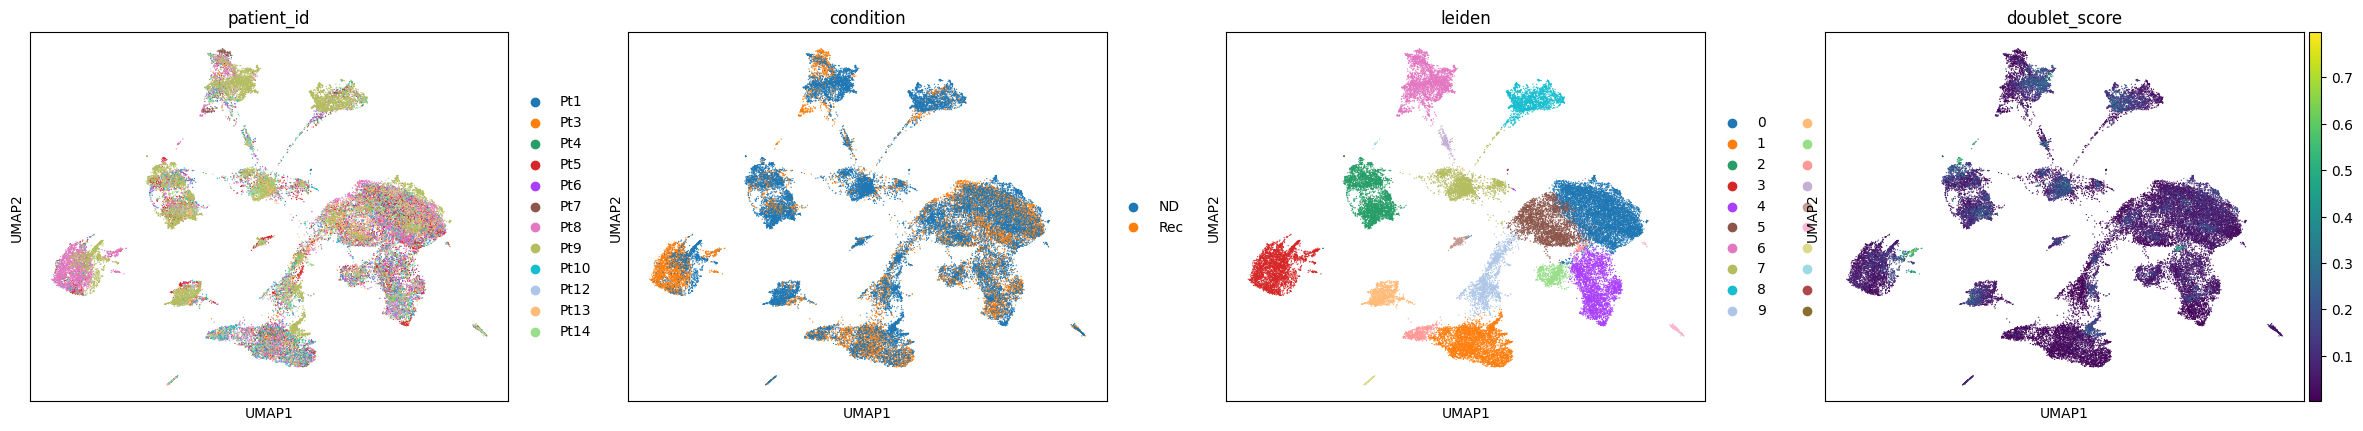

            mean  count
leiden                 
17      0.408726     22
19      0.216933      9
8       0.093904   1957
7       0.087629   2169
10      0.087033   1182
2       0.086701   3417
6       0.085460   2944
14      0.082554    271
13      0.075720    271
3       0.071335   3385
12      0.054600    694
0       0.048432   7599
11      0.046543    768
5       0.042779   3248
16      0.042323    146
9       0.039099   1709
4       0.038625   3258
1       0.030592   4063
15      0.026330    243
18      0.019276     11


In [ ]:
adata = sc.read_h5ad(ckpt_dir / 'part3_Clustered.h5ad')

# Key visualization: Are patients mixed? Where are the doublets?
sc.pl.umap(adata, color=['patient_id', 'condition', 'leiden', 'doublet_score'], 
           save='_final_diagnostic_umap.pdf')

# Helper table to decide what to delete
report = adata.obs.groupby('leiden', observed=True)['doublet_score'].agg(['mean', 'count'])
print(report.sort_values('mean', ascending=False))

<span style="color:olive; font-size:14px">**Interpreting the doublet score distribution by cluster**</span>:

| Cluster           | mean      | count     | Interpretation                                      |
| ----------------- | --------- | --------- | --------------------------------------------------- |
| 17                | 0.41      | 22        | 🔴 Pure doublet — very high score, very few cells |
| 19                | 0.22      | 9         | 🔴 Pure doublet — same pattern                      |
| 8, 7, 10, 2, 6... | 0.08–0.09 | 1000–3400 | 🟢 Real clusters — low score, many cells           |
| 18                | 0.019     | 11        | ⚠️ Few cells but low score — review                |

<span style="font-size:14px">**The general rule**: clusters with score > 0.15 + low count (< 50) = doublets to remove. Clusters 17 and 19 are clear candidates.</span>

<span style="color:orange; font-size:14px">**Check cluster 18. It has a low doublet score but also very few cells. It may be a rare cell type or it may be an artifact. We will check its marker genes and its position in the UMAP to decide whether to keep it or not.**</span>

<span style="font-size:14px">But, which number of cluster is each one? Let's tag them in the UMAP to see where they are located and have a better idea of what we are deleting. </span>

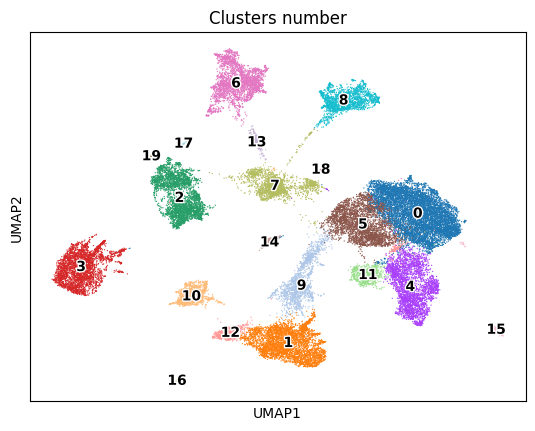

In [11]:
sc.pl.umap(adata, color='leiden', legend_loc='on data',
           legend_fontoutline=2, show=False, title='Clusters number')

plt.show()

<span style="font-size:14px; color:teal">**INSPECTION OF GENE MARKERS OF CLUSTER 18**</span>

<span style="font-size:13px">Before proceeding we need to check the layers of our AnnData object to see where the log-normalized counts are stored. This is crucial for performing differential expression analysis later on using the Wilcoxon test, which requires log-normalized counts. Given that we have preserved the raw_counts in adata.layers['raw_counts'], we'll use this layer to generate the 'log_norm' layer. This way, we can ensure that we have the appropriate data format for differential expression (DE) analysis.</span>

In [20]:
print("Layers disponibles:", list(adata.layers.keys()))

Layers disponibles: ['raw_counts']


In [21]:
check_ram()

RAM in use: 0.1 GB


In [ ]:
# Generate log-norm in a new layer from raw_counts
adata.layers['log_norm'] = adata.layers['raw_counts'].copy().astype(float)
sc.pp.normalize_total(adata, target_sum=1e4, layer='log_norm')
sc.pp.log1p(adata, layer='log_norm')
print("✅ log_norm created"); check_ram()

# Calculate markers for cluster 18 vs rest using the Wilcoxon test on the log-normalized counts in the 'log_norm' layer
sc.tl.rank_genes_groups(
    adata, groupby='leiden', groups=['18'],
    reference='rest', method='wilcoxon',
    layer='log_norm', use_raw=False
)

# Extract table and DELETE the log_norm layer immediately to free up RAM
df = sc.get.rank_genes_groups_df(adata, group='18')
del adata.layers['log_norm']
gc.collect()
print("✅ RAM freed"); check_ram()

# Final table
cluster_18 = df[['names','logfoldchanges','pvals','pvals_adj']].copy()
cluster_18.columns = ['Gene Symbol','log2FC','p-value','Adjusted p-value']
cluster_18['log2FC'] = cluster_18['log2FC'].round(3)
#print(cluster_18[cluster_18['Adjusted p-value'] < 0.05].head(15).to_string(index=False))
cluster_18[cluster_18['Adjusted p-value'] < 0.05].to_csv('cluster18_markers.csv', index=False)

   - <span style="color:teal; font-size:14px">**What is the adjusted p-value?**</span>

<span style="font-size:13px">The adjusted p-value, also known as the false discovery rate (FDR), is a statistical measure used to account for multiple comparisons in hypothesis testing. When performing multiple tests, the chance of obtaining a significant result by random chance increases. ***The adjusted p-value helps to control for this by adjusting the original p-values based on the number of tests performed***. A common method for adjusting p-values is the Benjamini-Hochberg procedure, which controls the expected proportion of false positives among the declared significant results. In our context, an adjusted p-value < 0.05 indicates that we can reject the null hypothesis for those genes while controlling for the false discovery rate at 5%.</span>                                

In [ ]:
cluster_18[cluster_18['Adjusted p-value'] < 0.05].head(15)  
#Adjusted p-value is

,Gene Symbol,log2FC,p-value,Adjusted p-value
0,IGHG4,8.421,1.262466e-08,0.000092
1,IGLC2,8.152,1.271698e-08,0.000092
2,IGHG1,8.105,1.309286e-08,0.000092
3,IGKC,7.907,1.552210e-08,0.000092
4,TYROBP,3.483,2.386899e-08,0.000092
5,S100A11,3.052,2.870160e-08,0.000092
6,HLA-DQA2,6.029,3.279230e-08,0.000092
7,C1QB,4.077,3.839613e-08,0.000092
8,C1QA,4.026,4.277841e-08,0.000092
9,CYBA,2.736,4.696600e-08,0.000092


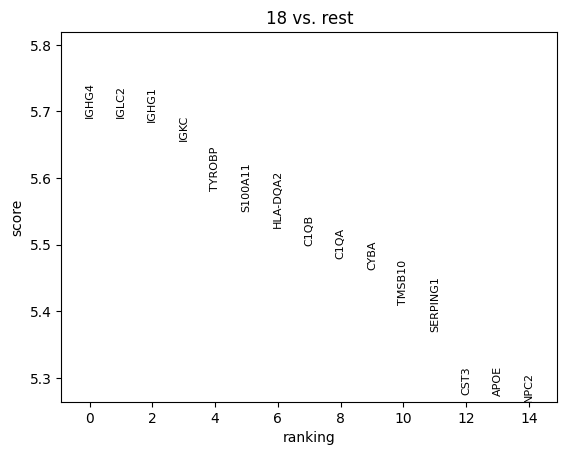

In [27]:
sc.pl.rank_genes_groups(adata, group='18', n_genes=15, sharey=False)

<span style="font-size:14px; color:red">**OBSERVATIONS**:

<span style="font-size:14px">This small cluster appears to represent a mixed plasma cell and macrophage/microglia signature rather than random noise.
The extremely high immunoglobulin expression suggests a strong plasma cell component, while myeloid markers indicate macrophage or microglial identity.
Overall, the cluster is most likely an artificial hybrid population caused by technical doublets or ambient RNA contamination.

- <span style="font-size:13px">**Strong plasma cell markers** (IGHG4, IGLC2, IGHG1, IGKC) show unusually high antibody-related expression.
- <span style="font-size:13px">**Classical myeloid markers** (TYROBP, APOE, C1QA, C1QB) confirm macrophage/microglia involvement.
- <span style="font-size:13px">**The most likely explanation is undetected technical doublets, despite low Scrublet scores.**
- <span style="font-size:13px; color: orange">**UMAP visualization using IGKC and APOE is recommended to confirm overlap and decide whether to remove the cluster before downstream analysis**

<span style="color:plum; font-size:14px"> To confirm whether it's a doublet or ambient RNA contamination, the best approach is to visually compare the expression of the two lineages (**plasma cell markers like IGKC vs myeloid markers like APOE**) on the UMAP. If the cells in cluster 18 show high expression of both IGKC and APOE, it would strongly suggest that they are doublets containing both plasma cell and myeloid RNA. If they only show high expression of one lineage, it may indicate ambient RNA contamination or a rare hybrid cell type. This visual confirmation will help us decide whether to remove cluster 18 from downstream analyses.</span>

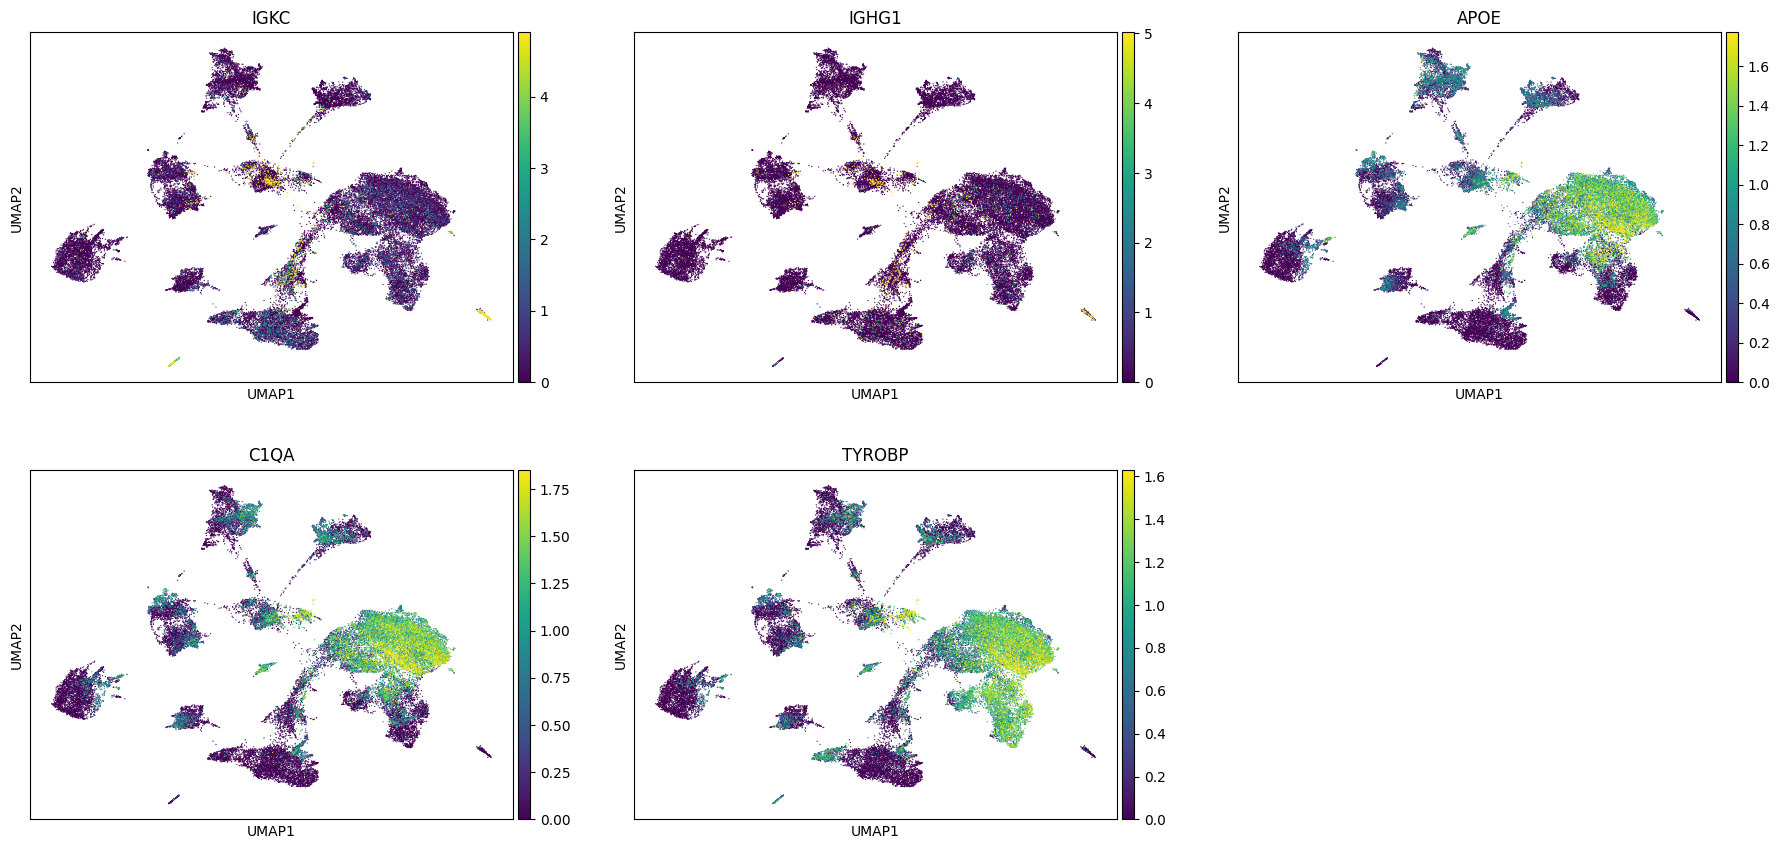

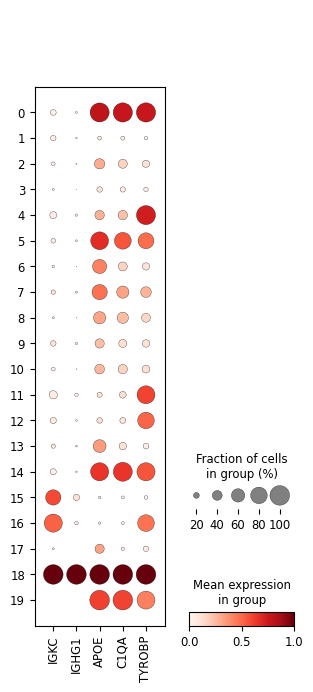

In [31]:
# 1. Define key markers of the two lineages detected in cluster 18 (plasma cell and myeloid)
genes_check = ['IGKC', 'IGHG1', 'APOE', 'C1QA', 'TYROBP']

# 2. UMAP visualization
sc.pl.umap(adata, 
           color=genes_check, 
           ncols=3, 
           vmin=0, 
           vmax='p99', # To avoid outliers overshadowing the signal
           save='_check_doublet_clusters.pdf')

# 3. Visualize the distribution by cluster (DotPlot is best for this)
sc.pl.dotplot(adata, 
              var_names=genes_check, 
              groupby='leiden', 
              standard_scale='var', 
              save='_dotplot_doublet_check.pdf')


<span style="color: dodgerblue; font-size:14px">This DotPlot provides strong evidence that cluster 18 is a **technical doublet or cell aggregate rather than a true biological population**. The cluster simultaneously shows maximal expression of both plasma cell markers and macrophage markers across nearly all cells, which is biologically unrealistic. Comparison with the “pure” clusters confirms that plasma cell and myeloid signatures are normally separated in the dataset.

- <span style="font-size:13px">Cluster 18 strongly co-expresses plasma cell genes (IGKC, IGHG1) and macrophage genes (APOE, C1QA, TYROBP).
- <span style="font-size:13px">Pure macrophage clusters (0, 5, 14, 19) express APOE/C1QA but lack IGKC expression.
- <span style="font-size:13px">Pure plasma/B-cell clusters (15, 16) express IGKC but do not express myeloid markers.
- <span style="font-size:13px">The most likely explanation is a technical capture artifact where two different cell types were encapsulated in the same droplet.


<span style="color:olive; font-size:22px">**DOUBLET REMOVAL**</span>

<span style="font-size:14px">Before removing any cluster or doublet, we will check how many predicted doublets we have in total out of the clusters we have identified as doublets.</span>

In [33]:
doublet_clusters = ['17', '18', '19']
mask_cluster   = adata.obs['leiden'].isin(doublet_clusters)
mask_predicted = adata.obs['predicted_doublet'] == True

# Cell Scrublet marked as doublets but are NOT in clusters 17/18/19
mask_outside = mask_predicted & ~mask_cluster

print(f"Total predicted_doublet=True:          {mask_predicted.sum():,}")
print(f"  → Inside 17/18/19:          {(mask_predicted & mask_cluster).sum():,}")
print(f"  → Outside 17/18/19:           {mask_outside.sum():,} ({mask_outside.mean()*100:.2f}% of total)")
print()
print("By cluster (outside):")
print(adata.obs.loc[mask_outside, 'leiden'].value_counts())

Total predicted_doublet=True:          361
  → Inside 17/18/19:          20
  → Outside 17/18/19:           341 (0.91% of total)

By cluster (outside):
leiden
3     152
2      65
12     49
6      24
7      14
0       9
4       7
1       4
9       4
8       3
13      3
5       2
10      2
11      1
15      1
16      1
14      0
17      0
18      0
19      0
Name: count, dtype: int64


<span style="font-size:14px">Cleaning that 0.91% of doublets scattered in cluster 3 (and others) removes "dirty points" that could appear as false positives in your gene comparison. With 12 patients, the purity of the dataset is what will give us the necessary statistical power.</span>

In [34]:
# 1. List of clusters to remove based on leiden table report and DotPlot/UMAP inspection
clusters_to_remove = ['17', '18', '19']

# 2. Apply the filter:
# Keep cells that are NOT in those clusters AND that were NOT marked by Scrublet
adata_final = adata[
    (~adata.obs['leiden'].isin(clusters_to_remove)) & 
    (adata.obs['predicted_doublet'] == False)
].copy()

print(f"Removed cells by cluster : {adata.obs['leiden'].isin(clusters_to_remove).sum()}")
print(f"Cells removed by Scrublet (outside those clusters): {adata.n_obs - adata_final.n_obs - adata.obs['leiden'].isin(clusters_to_remove).sum()}")
print(f"Total clean cells for analysis: {adata_final.n_obs:,}")

# 3. Save the final object
adata_final.write_h5ad(ckpt_dir / 'final_clean_adata.h5ad')
print("Finally, we have a clean AnnData object ready for downstream analysis 🎉!!")
del adata, adata_final; gc.collect()
check_ram()

Removed cells by cluster : 42
Cells removed by Scrublet (outside those clusters): 341
Total clean cells for analysis: 36,983
Finally, we have a clean AnnData object ready for downstream analysis 🎉!!
RAM in use: 0.9 GB


normalizing counts per cell
    finished (0:00:00)


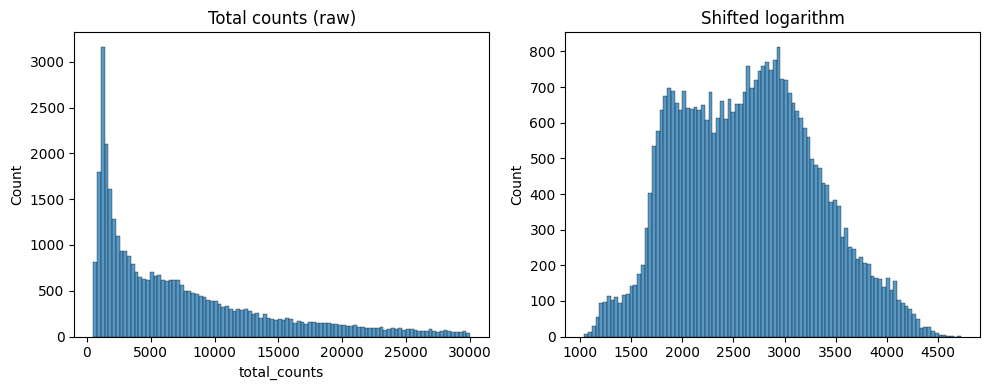

19736

In [ ]:
"""""
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Cargar solo lo necesario
adata = sc.read_h5ad(ckpt_dir / 'part1_hvg.h5ad')

# 2) TOTAL COUNTS (RAW)  ─────────────────────────────────────────────
# Usamos la capa raw_counts si existe
X_raw = adata.layers['raw_counts'] if 'raw_counts' in adata.layers else adata.X

total_raw = X_raw.sum(axis=1)   # sigue siendo matriz columna
if hasattr(total_raw, 'A1'):    # si es matriz dispersa/matriz de numpy
    total_raw = total_raw.A1    # vector 1D sin densificar toda la matriz grande

# 3) NORMALIZACIÓN (pre-log) SIN MODIFICAR adata.X  ─────────────────
# Esto devuelve un dict con la matriz normalizada 'X', sin tocar adata.X
norm_res = sc.pp.normalize_total(adata, target_sum=1e4, inplace=False)
X_norm = norm_res['X']          # matriz normalizada (sigue siendo dispersa)

total_prelog = X_norm.sum(axis=1)
if hasattr(total_prelog, 'A1'):
    total_prelog = total_prelog.A1

# 4) (OPCIONAL) APLICAR LOG1P SOLO PARA EL SEGUNDO HISTOGRAMA  ──────
# Si quieres comparar "raw" vs "normalized + log"
X_norm_log = X_norm.copy()
X_norm_log.data = np.log1p(X_norm_log.data)

total_norm_log = X_norm_log.sum(axis=1)
if hasattr(total_norm_log, 'A1'):
    total_norm_log = total_norm_log.A1

# 5) FIGURA COMPARATIVA (ejemplo: raw vs normalized+log)  ───────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Panel izquierdo: raw
sns.histplot(total_raw, bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts (raw)")
axes[0].set_xlabel("total_counts")
axes[0].set_ylabel("Count")

# Panel derecho: después de normalizar + log
sns.histplot(total_norm_log, bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")

plt.tight_layout()
plt.show()

# 6) Liberar memoria ────────────────────────────────────────────────
del X_raw, X_norm, X_norm_log
del total_raw, total_prelog, total_norm_log
del norm_res
del adata
gc.collect()

normalizing counts per cell
    finished (0:00:00)


c:\Users\dioul\miniconda3\envs\scrna\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA


c:\Users\dioul\miniconda3\envs\scrna\lib\site-packages\scanpy\preprocessing\_pca\__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


    with n_comps=50
    finished (0:00:15)


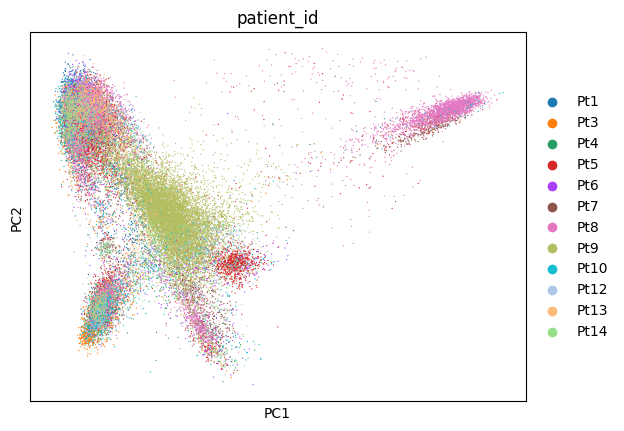

5368

In [ ]:
""""
adata = sc.read_h5ad(ckpt_dir / 'part1_hvg.h5ad')

# Normalization and dimensionality reduction (PCA)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Initial PCA 
sc.pp.scale(adata, max_value=10)            # Scale consume RAM al densificar la matriz
sc.tl.pca(adata, n_comps=50, use_highly_variable=True)      #We calculate 50 PCs to have a full picture of variance structure.
sc.pl.pca(adata, color='patient_id', save='_pca_initial.pdf')  # PCA colored by patient to visualize batch effects
plt.show()


# Save the integrated data for clustering and visualization
#adata.write_h5ad(ckpt_dir / 'part2_PCA.h5ad')
del adata; gc.collect()